Part 1 - Building and Understanding GANs from Scratch

In [1]:
# ----- Environment -----
import math
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# A single global seed keeps every run in this notebook reproducible.
RNG_SEED = 7
torch.manual_seed(RNG_SEED)
np.random.seed(RNG_SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Running on:", DEVICE)

# --- consistent, clean plot styling for every figure in this notebook ---
plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 120, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 11, "legend.fontsize": 9, "legend.framealpha": 0.9,
    "axes.grid": True, "grid.alpha": 0.25, "axes.axisbelow": True,
    "axes.spines.top": False, "axes.spines.right": False,
})


Running on: cuda


1. Target distributions

In [2]:
def sample_sine(n_points=1024):
    """Reference target: points lying on y = sin(x), x in [0, 2*pi)."""
    x = 2.0 * math.pi * torch.rand(n_points)
    y = torch.sin(x)
    return torch.stack((x, y), dim=1)


def sample_wiggly_curve(n_points=1024, noise_sd=0.05):
    """Noisy parametric curve  y = sin(2x) + 0.3 cos(5x) + eps.

    The two harmonics give the curve several turning points, so a generator that
    only learns the low-frequency component will visibly miss the ripples.
    """
    x = 2.0 * math.pi * torch.rand(n_points)
    y = torch.sin(2.0 * x) + 0.3 * torch.cos(5.0 * x)
    y = y + noise_sd * torch.randn(n_points)
    return torch.stack((x, y), dim=1)


def sample_gaussian_ring(n_points=4096, n_modes=8, ring_radius=2.0, blob_sd=0.10):
    """Mixture of `n_modes` isotropic Gaussians spaced evenly on a circle.

    Returns both the samples and the array of mode centres so coverage can be
    measured later.
    """
    angles = np.linspace(0.0, 2.0 * np.pi, n_modes, endpoint=False)
    centres = np.column_stack((ring_radius * np.cos(angles),
                               ring_radius * np.sin(angles)))
    pick = np.random.randint(0, n_modes, size=n_points)
    pts = centres[pick] + blob_sd * np.random.randn(n_points, 2)
    return torch.tensor(pts, dtype=torch.float32), centres

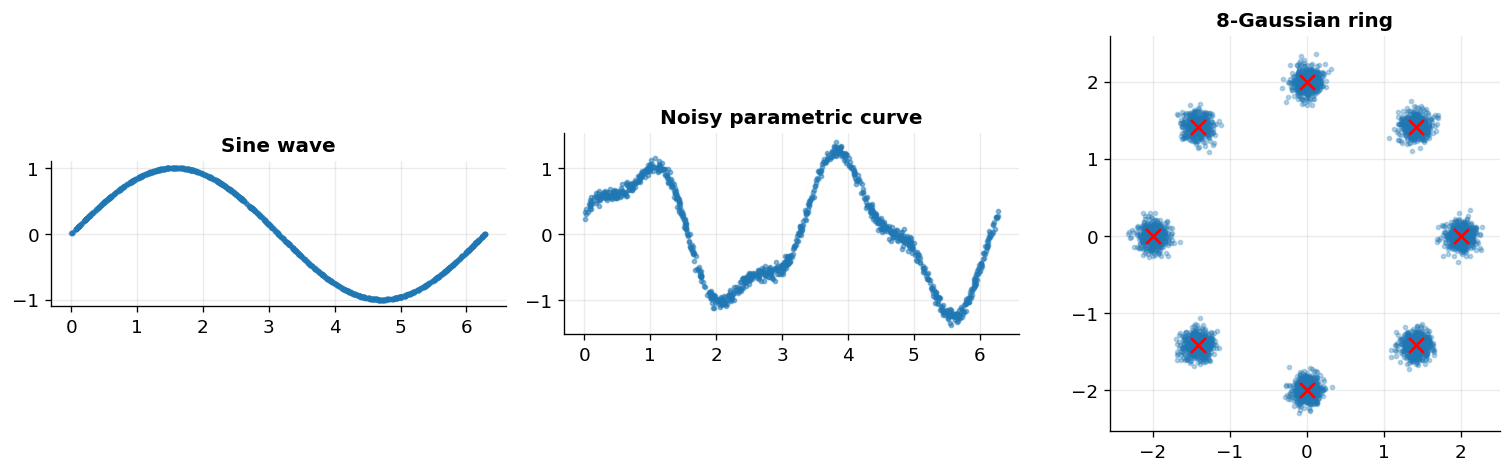

In [3]:
# Quick look at the three targets before any training happens.
fig, ax = plt.subplots(1, 3, figsize=(13, 4))
ax[0].scatter(*sample_sine().T, s=6, alpha=.5);            ax[0].set_title("Sine wave")
ax[1].scatter(*sample_wiggly_curve().T, s=6, alpha=.5);    ax[1].set_title("Noisy parametric curve")
ring, ring_centres = sample_gaussian_ring()
ax[2].scatter(*ring.T, s=6, alpha=.3)
ax[2].scatter(*ring_centres.T, c="red", marker="x", s=80); ax[2].set_title("8-Gaussian ring")
for a in ax: a.set_aspect("equal")
plt.tight_layout(); plt.show()

2. Network builder

In [4]:
def make_mlp(sizes, hidden_act, final_act=None, batchnorm=False, dropout=0.0):
    """Build a sequential MLP from a list of layer widths.

    sizes       : e.g. [2, 64, 64, 1]  -> input 2, two hidden layers, output 1
    hidden_act  : activation module constructor used between hidden layers
    final_act   : optional activation on the output (e.g. nn.Sigmoid for the critic)
    batchnorm   : insert BatchNorm1d after each hidden linear layer
    dropout     : dropout probability applied after each hidden activation
    """
    layers = []
    for i in range(len(sizes) - 1):
        layers.append(nn.Linear(sizes[i], sizes[i + 1]))
        is_last = (i == len(sizes) - 2)
        if not is_last:
            if batchnorm:
                layers.append(nn.BatchNorm1d(sizes[i + 1]))
            layers.append(hidden_act())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
    if final_act is not None:
        layers.append(final_act())
    return nn.Sequential(*layers)


def baseline_pair(latent_dim=2):
    """Tutorial-style ReLU networks (our reproduction baseline)."""
    gen = make_mlp([latent_dim, 16, 32, 2], hidden_act=nn.ReLU)
    disc = make_mlp([2, 256, 128, 64, 1], hidden_act=nn.ReLU,
                    final_act=nn.Sigmoid, dropout=0.3)
    return gen, disc


def revised_pair(latent_dim=4):
    """Revised architecture: wider generator with BatchNorm, LeakyReLU critic.

    The changes target the two classic failure modes of the baseline: a BatchNorm
    generator spreads probability mass more evenly (helps mode coverage), and the
    LeakyReLU critic keeps gradients alive on negative pre-activations.
    """
    leaky = lambda: nn.LeakyReLU(0.2)
    gen = make_mlp([latent_dim, 64, 128, 64, 2], hidden_act=leaky, batchnorm=True)
    disc = make_mlp([2, 128, 128, 64, 1], hidden_act=leaky,
                    final_act=nn.Sigmoid, dropout=0.2)
    return gen, disc

3. Training routine

In [5]:
def adversarial_fit(gen, disc, data, latent_dim,
                    epochs=800, batch_size=64, lr=1e-3,
                    real_target=0.9, noise_sd0=0.0):
    """Train a generator/discriminator pair with the non-saturating BCE game.

    Returns per-epoch mean discriminator and generator losses.
    """
    gen, disc = gen.to(DEVICE), disc.to(DEVICE)
    bce = nn.BCELoss()
    # betas follow the DCGAN convention; momentum term lowered to 0.5.
    opt_g = torch.optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(disc.parameters(), lr=lr, betas=(0.5, 0.999))

    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(data),
        batch_size=batch_size, shuffle=True, drop_last=True)

    d_curve, g_curve = [], []
    for epoch in range(epochs):
        # Linear anneal of the instance-noise standard deviation -> 0 by 60% through.
        noise_sd = noise_sd0 * max(0.0, 1.0 - epoch / (0.6 * epochs))
        d_run = g_run = steps = 0

        for (real_batch,) in loader:
            real_batch = real_batch.to(DEVICE)
            bs = real_batch.size(0)
            ones = torch.full((bs, 1), real_target, device=DEVICE)
            zeros = torch.zeros((bs, 1), device=DEVICE)

            # ---- discriminator update ----
            z = torch.randn(bs, latent_dim, device=DEVICE)
            fake_batch = gen(z).detach()
            if noise_sd > 0:
                real_in = real_batch + noise_sd * torch.randn_like(real_batch)
                fake_in = fake_batch + noise_sd * torch.randn_like(fake_batch)
            else:
                real_in, fake_in = real_batch, fake_batch
            disc.zero_grad()
            d_loss = bce(disc(real_in), ones) + bce(disc(fake_in), zeros)
            d_loss.backward(); opt_d.step()

            # ---- generator update (non-saturating: maximise log D(G(z))) ----
            z = torch.randn(bs, latent_dim, device=DEVICE)
            gen.zero_grad()
            g_loss = bce(disc(gen(z)), ones)
            g_loss.backward(); opt_g.step()

            d_run += d_loss.item(); g_run += g_loss.item(); steps += 1

        d_curve.append(d_run / steps); g_curve.append(g_run / steps)
    return d_curve, g_curve


@torch.no_grad()
def draw_samples(gen, latent_dim, n=1000):
    """Sample n points from a trained generator and return them as a NumPy array."""
    gen.eval()
    z = torch.randn(n, latent_dim, device=DEVICE)
    out = gen(z).cpu().numpy()
    gen.train()
    return out

In [6]:
def show_run(real, fake, d_curve, g_curve, title, centres=None):
    """Side-by-side scatter of real vs generated points and the loss curves."""
    fig, (axL, axR) = plt.subplots(1, 2, figsize=(12, 4.2))
    axL.scatter(real[:, 0], real[:, 1], s=7, alpha=.45, label="real")
    axL.scatter(fake[:, 0], fake[:, 1], s=7, alpha=.45, label="generated")
    if centres is not None:
        axL.scatter(centres[:, 0], centres[:, 1], c="black", marker="x", s=70, label="modes")
    axL.set_xlabel("x"); axL.set_ylabel("y")
    axL.set_title(title); axL.legend(); axL.set_aspect("equal")
    axR.plot(d_curve, label="D loss"); axR.plot(g_curve, label="G loss")
    axR.axhline(math.log(2), ls="--", c="grey", lw=.8, label="ln 2 (ideal D)")
    axR.set_xlabel("epoch"); axR.set_title("Training losses"); axR.legend()
    plt.tight_layout(); plt.show()

4. Task 1.1 - Reproduce the sine-wave GAN (baseline)

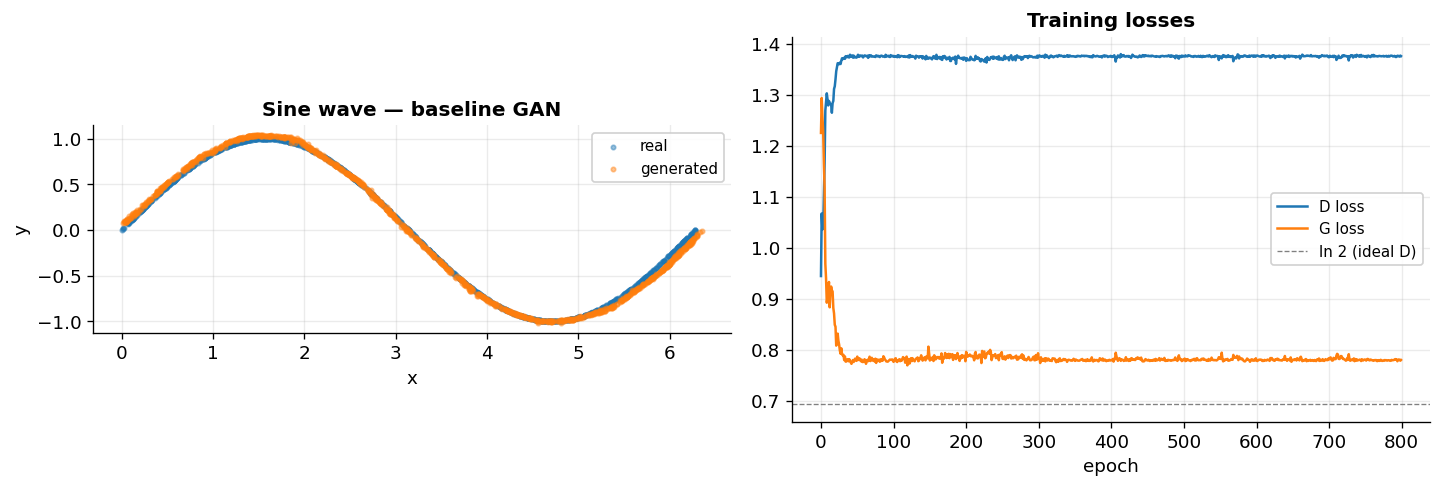

In [7]:
torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)
sine = sample_sine()
g_sine, d_sine = baseline_pair(latent_dim=2)
dc, gc = adversarial_fit(g_sine, d_sine, sine, latent_dim=2, epochs=800, batch_size=32)
show_run(sine.numpy(), draw_samples(g_sine, 2), dc, gc, "Sine wave — baseline GAN")

5. Task 1.2 - New distribution with the revised architecture

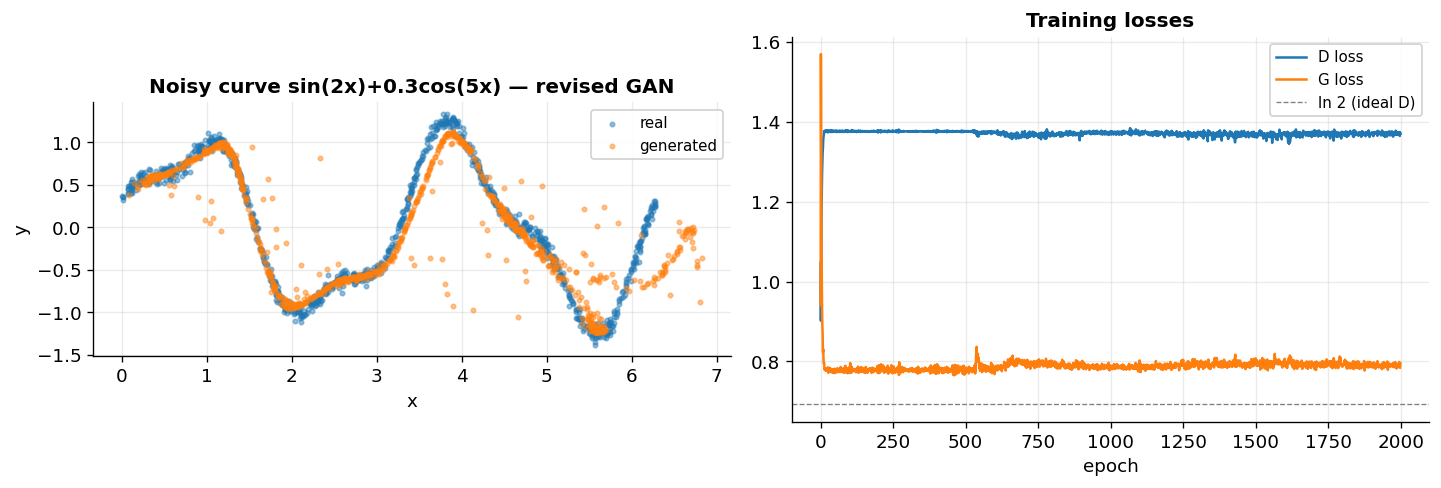

In [8]:
torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)
curve = sample_wiggly_curve()
# latent_dim=2 (curve is a 1-D manifold; less latent capacity = less spurious spread)
# noise_sd0=0.0 (instance noise blurs a thin curve; keep it only for the multimodal ring)
g_curve_net, d_curve_net = revised_pair(latent_dim=2)
dc, gc = adversarial_fit(g_curve_net, d_curve_net, curve, latent_dim=2,
                         epochs=2000, batch_size=64, noise_sd0=0.0)
show_run(curve.numpy(), draw_samples(g_curve_net, 2), dc, gc,
         "Noisy curve sin(2x)+0.3cos(5x) — revised GAN")

6. Task 1.3 - Mode collapse on the 8-Gaussian ring

In [9]:
def mode_recall(samples, centres, capture_radius=0.5):
    """Fraction of modes that capture a meaningful share of generated samples.

    Returns (n_modes_hit, recall_fraction, per_mode_counts).
    A point counts towards a mode only if it lands within `capture_radius` of it.
    """
    d = np.linalg.norm(samples[:, None, :] - centres[None, :, :], axis=2)
    nearest = d.argmin(axis=1)
    hit = d[np.arange(len(samples)), nearest] < capture_radius
    counts = np.bincount(nearest[hit], minlength=len(centres))
    # a mode is "covered" if it holds at least 1% of the captured mass
    covered = (counts > 0.01 * max(counts.sum(), 1)).sum()
    return covered, covered / len(centres), counts

Modes covered : 8/8
Mode recall   : 1.00
Per-mode count: [273, 321, 239, 247, 194, 228, 221, 240]


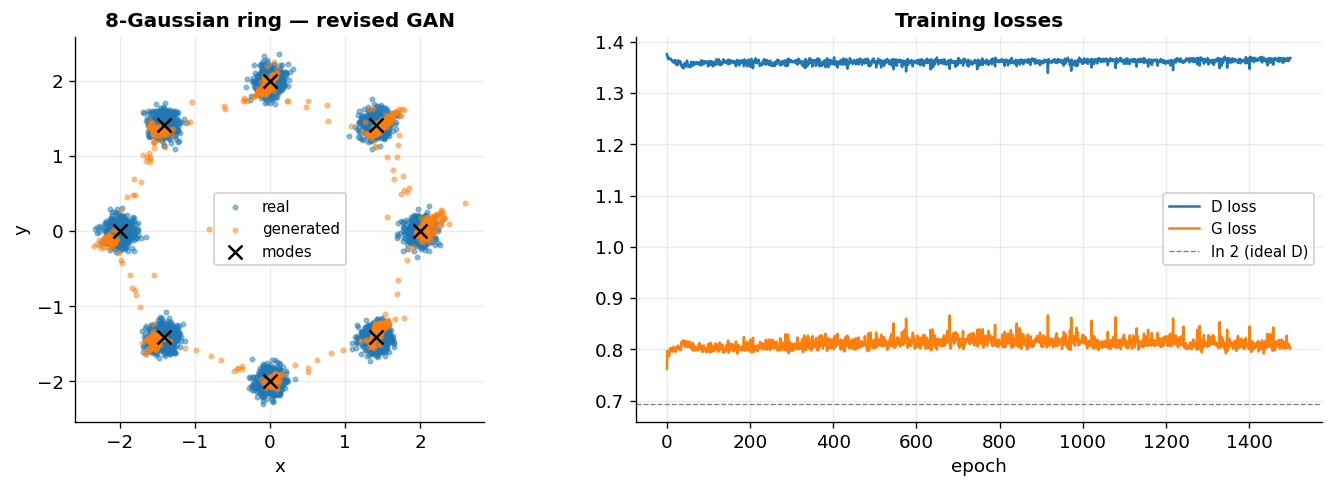

In [10]:
torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)
ring, ring_centres = sample_gaussian_ring(n_points=4096, n_modes=8)
g_ring, d_ring = revised_pair(latent_dim=4)
dc, gc = adversarial_fit(g_ring, d_ring, ring, latent_dim=4,
                         epochs=1500, batch_size=128, noise_sd0=0.1)
fake_ring = draw_samples(g_ring, 4, n=2000)

hit, recall, counts = mode_recall(fake_ring, ring_centres)
print(f"Modes covered : {hit}/8")
print(f"Mode recall   : {recall:.2f}")
print(f"Per-mode count: {counts.tolist()}")
show_run(ring.numpy(), fake_ring, dc, gc,
         "8-Gaussian ring — revised GAN", centres=ring_centres)

7. Architecture comparison (baseline vs revised)

In [11]:
def quick_ring_score(pair_fn, latent_dim, epochs=900, noise_sd0=0.0):
    torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)
    data, centres = sample_gaussian_ring(n_points=2048, n_modes=8)
    gen, disc = pair_fn(latent_dim=latent_dim)
    adversarial_fit(gen, disc, data, latent_dim=latent_dim,
                    epochs=epochs, batch_size=128, noise_sd0=noise_sd0)
    hit, recall, _ = mode_recall(draw_samples(gen, latent_dim, n=1500), centres)
    return hit, recall

configs = [
    ("Baseline (ReLU, no tricks)",      baseline_pair, 2, 0.0),
    ("Revised (BN+LeakyReLU+smooth)",   revised_pair,  4, 0.0),
    ("Revised + instance noise",        revised_pair,  4, 0.1),
]
print(f"{'configuration':<34}{'modes':>8}{'recall':>9}")
print("-" * 51)
for name, fn, ld, ns in configs:
    hit, recall = quick_ring_score(fn, ld, noise_sd0=ns)
    print(f"{name:<34}{hit:>6}/8{recall:>9.2f}")

configuration                        modes   recall
---------------------------------------------------
Baseline (ReLU, no tricks)             4/8     0.50
Revised (BN+LeakyReLU+smooth)          8/8     1.00
Revised + instance noise               8/8     1.00


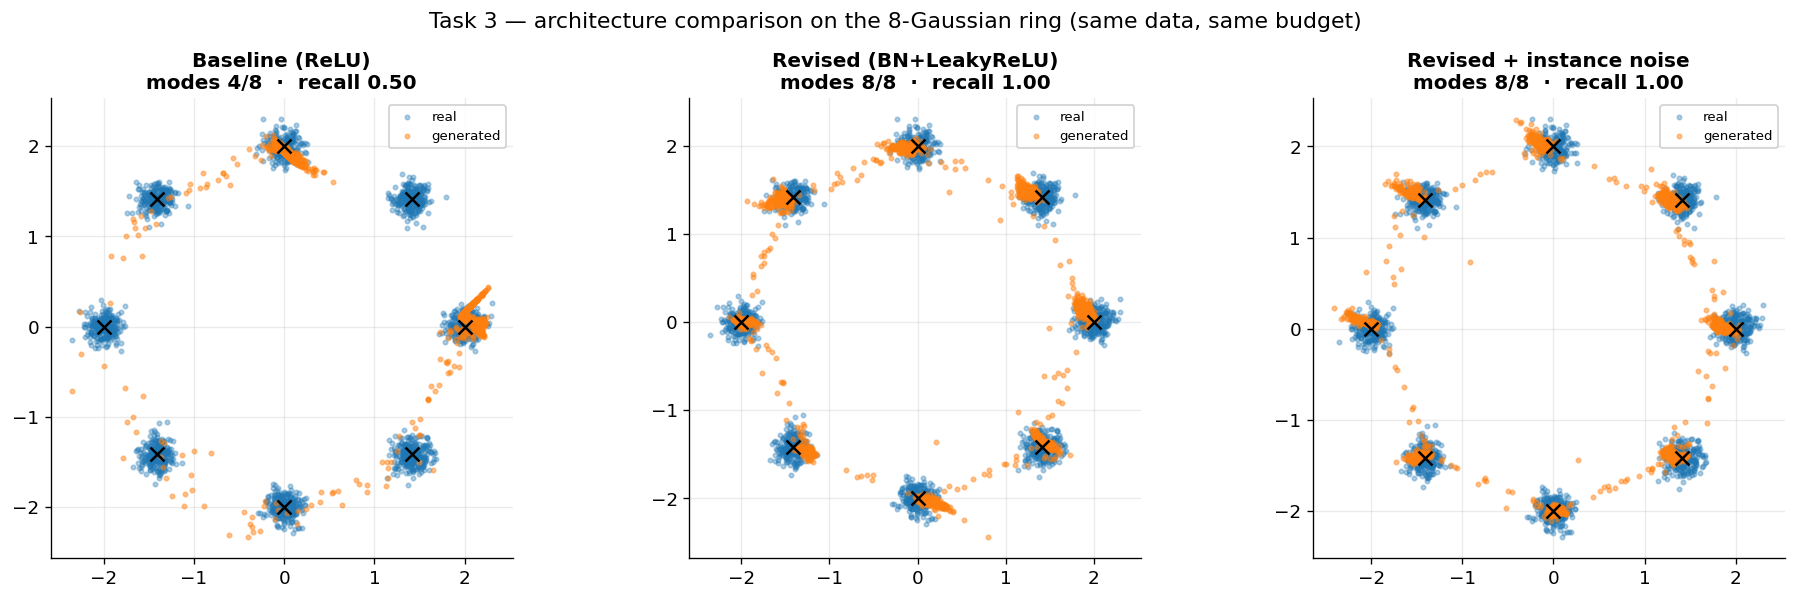

In [12]:
# Task 3 — DIRECT visual comparison: identical target & budget, only architecture differs.
def train_ring_for_plot(pair_fn, latent_dim, epochs=900, noise_sd0=0.0):
    """Train one configuration on the ring and return real, generated, centres + recall."""
    torch.manual_seed(RNG_SEED); np.random.seed(RNG_SEED)
    data, centres = sample_gaussian_ring(n_points=2048, n_modes=8)
    gen, disc = pair_fn(latent_dim=latent_dim)
    adversarial_fit(gen, disc, data, latent_dim=latent_dim,
                    epochs=epochs, batch_size=128, noise_sd0=noise_sd0)
    fake = draw_samples(gen, latent_dim, n=1500)
    hit, recall, _ = mode_recall(fake, centres)
    return data.numpy(), fake, centres, hit, recall

panels = [
    ("Baseline (ReLU)",          baseline_pair, 2, 0.0),
    ("Revised (BN+LeakyReLU)",   revised_pair,  4, 0.0),
    ("Revised + instance noise", revised_pair,  4, 0.1),
]
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, fn, ld, ns) in zip(axes, panels):
    real, fake, centres, hit, recall = train_ring_for_plot(fn, ld, noise_sd0=ns)
    ax.scatter(real[:, 0], real[:, 1], s=7, alpha=.35, label="real")
    ax.scatter(fake[:, 0], fake[:, 1], s=7, alpha=.45, label="generated")
    ax.scatter(centres[:, 0], centres[:, 1], c="black", marker="x", s=70)
    ax.set_title(f"{name}\nmodes {hit}/8  ·  recall {recall:.2f}")
    ax.set_aspect("equal"); ax.legend(loc="upper right", fontsize=8)
plt.suptitle("Task 3 — architecture comparison on the 8-Gaussian ring (same data, same budget)")
plt.tight_layout(); plt.show()